In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip3 install xgboost shap

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Features to remove: 20
Features being dropped: ['feature_17', 'feature_33', 'feature_53', 'feature_08', 'feature_15', 'feature_73', 'feature_31', 'feature_21', 'feature_50', 'feature_26', 'feature_32', 'feature_27', 'feature_39', 'feature_58', 'feature_41', 'feature_42', 'feature_52', 'feature_55', 'feature_44', 'feature_74']
Number of features after removal: 59
Remaining feature columns: ['feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_09', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_16', 'feature_18', 'feature_19', 'feature_20', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_28', 'feature_29', 'feature_30', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_40', 'feature_43', 'feature_45', 'feature_46', 'f

/tmp/ipython-input-409982017.py:80: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).select(feature_cols).collect(streaming=True)


Computed means for 59 features

len_train = 22104280
len_ofl_mdl = 20999066
---> Last offline train date = 1669

Verifying imputation...
Total nulls in feature columns (sample): 0

Feature means saved to 'feature_means.npy'

PREPROCESSING SUMMARY
Original features: 79
Features removed: 20
Remaining features: 59
Lag features added: 9
Total features for training: 68
Training samples: ~20,999,066
Validation samples: ~1,105,214
Visualization sample size: 100,000 rows


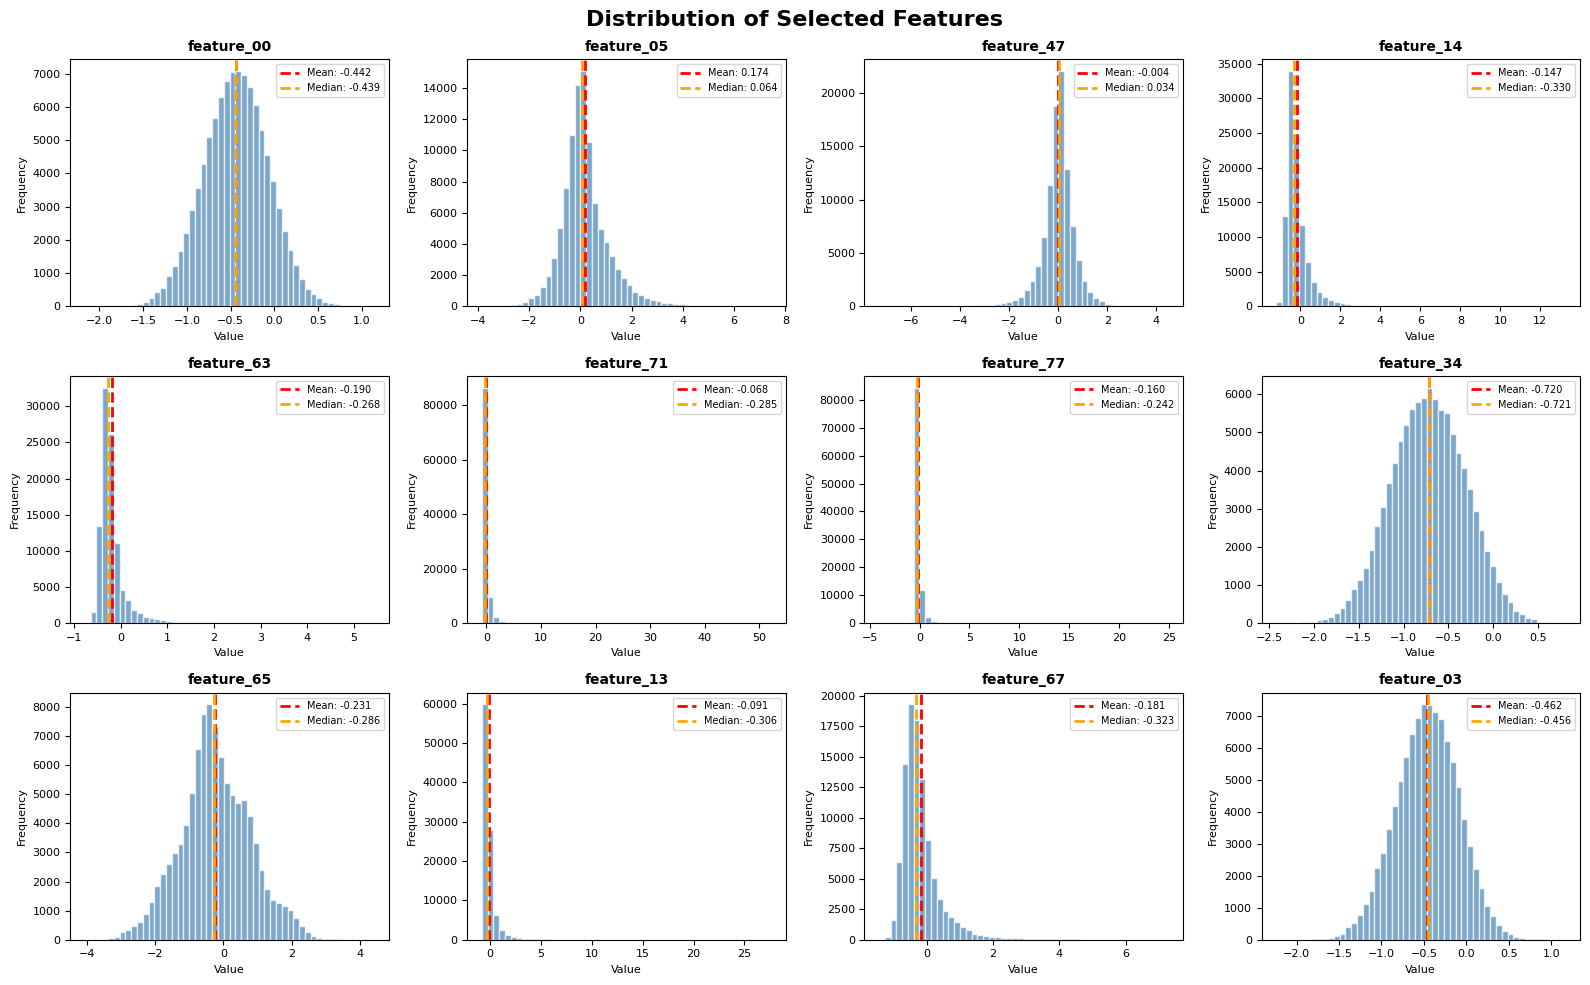

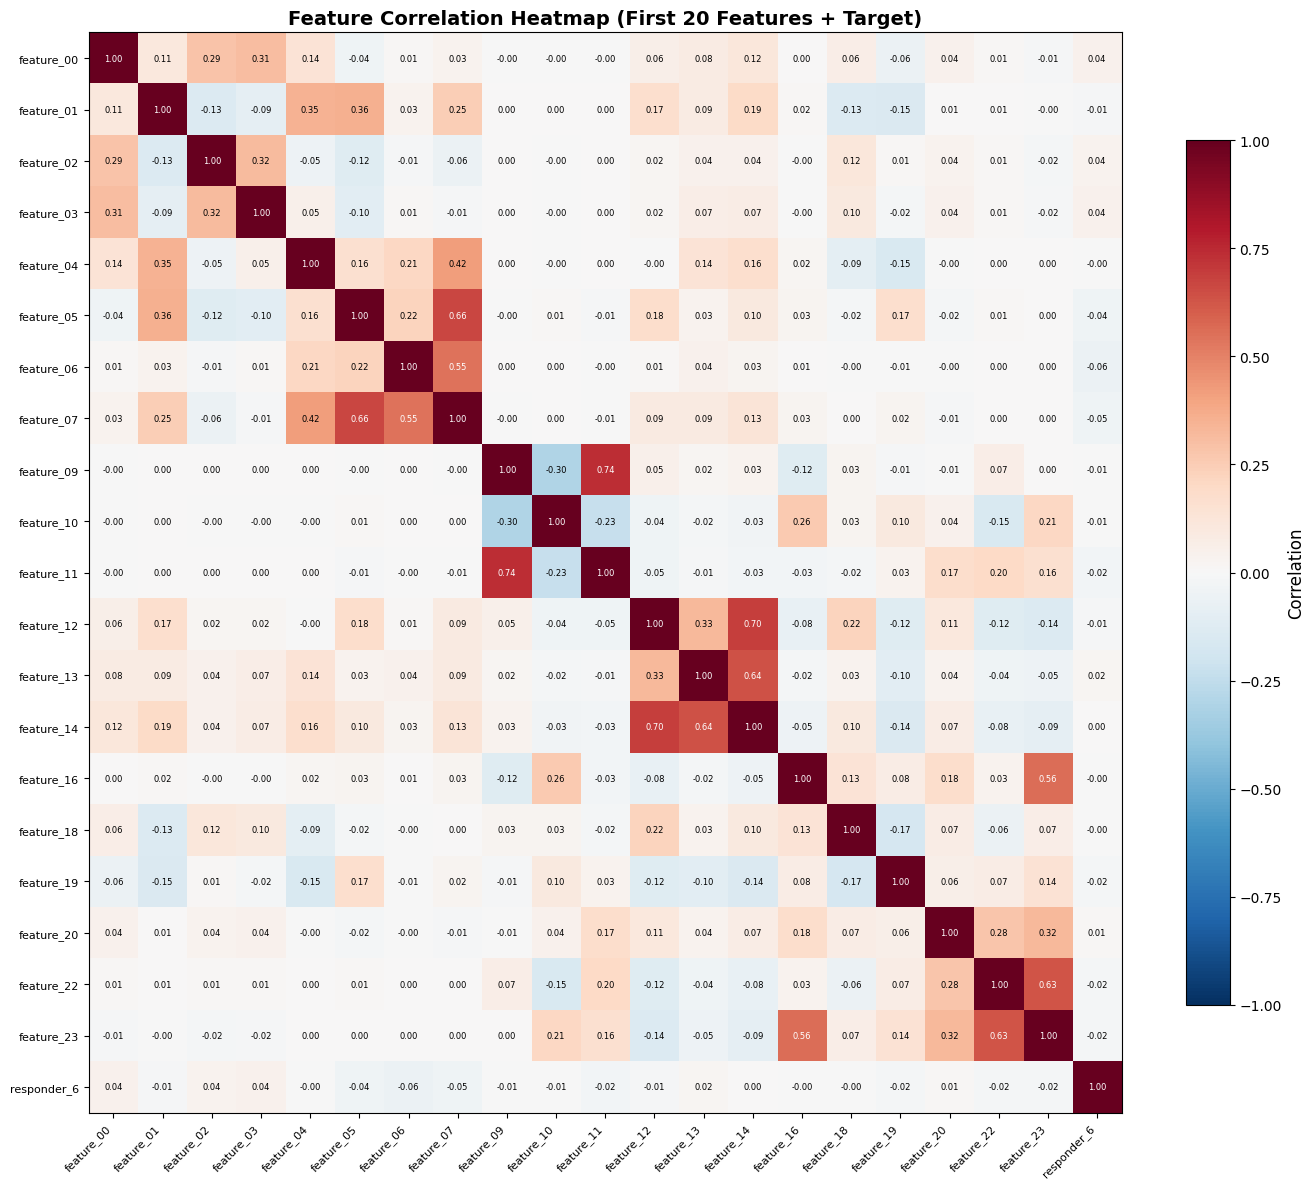

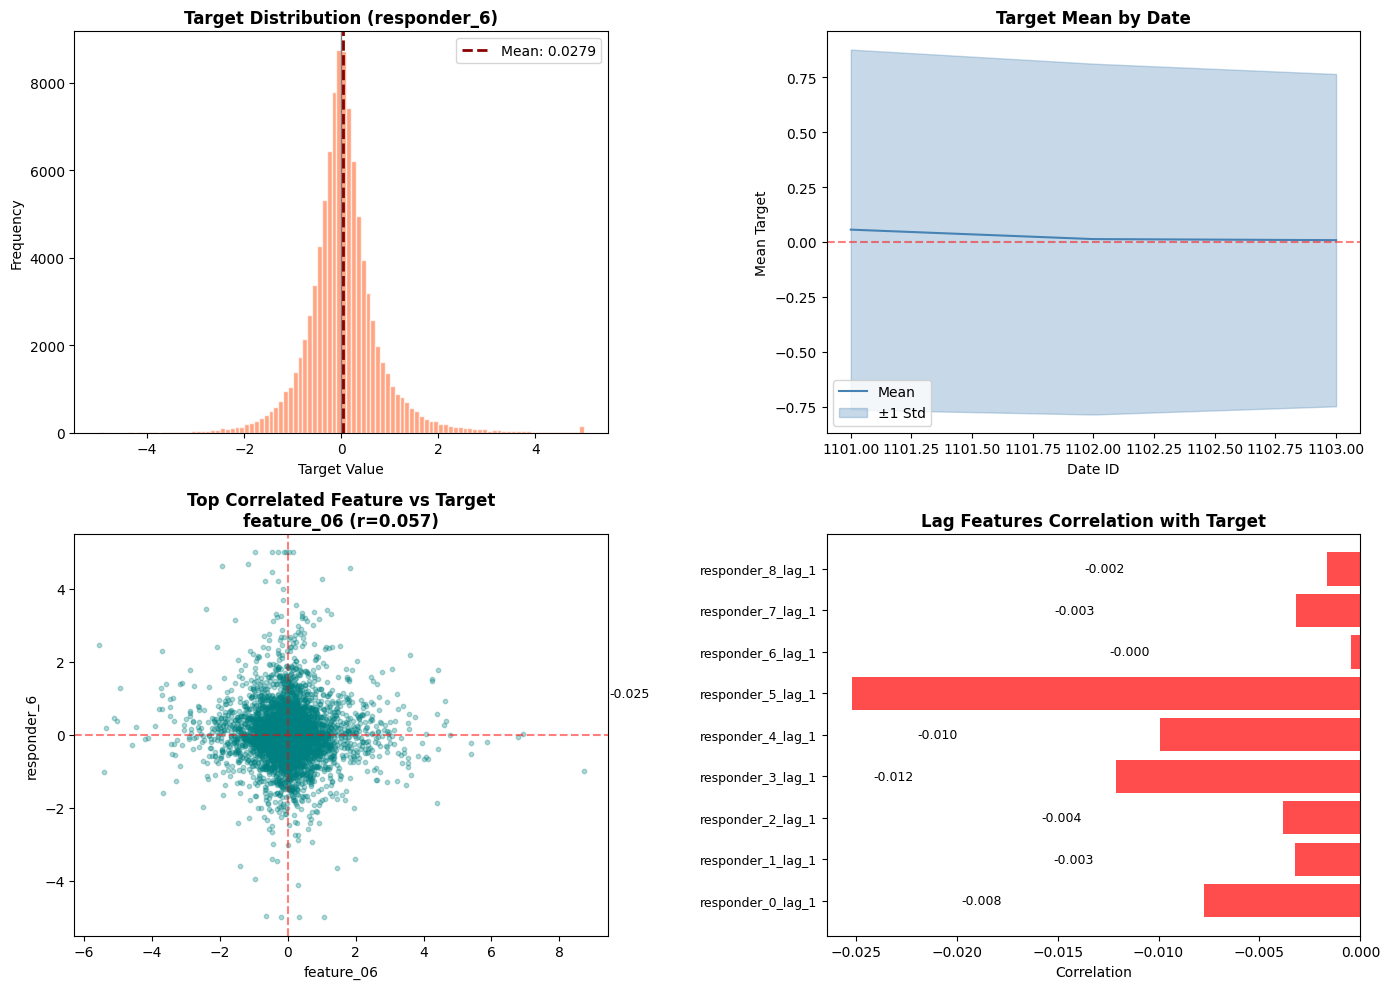


VISUALIZATION SUMMARY
1. feature_distributions.png - Distribution of 12 random features
2. correlation_heatmap.png - Correlation matrix of top 20 features
3. target_analysis.png - Target distribution and feature relationships
PREPARING DATA FOR XGBOOST
Number of feature columns: 59
Number of lag features: 9
Total features: 68

Training data collected in 7.16s
X_train shape: (21022056, 68)
y_train shape: (21022056,)

Validation data collected in 4.78s
X_valid shape: (1082224, 68)
y_valid shape: (1082224,)

Creating XGBoost DMatrices...

TRAINING XGBOOST MODEL

Parameters:
  objective: reg:squarederror
  eval_metric: rmse
  booster: gbtree
  learning_rate: 0.05
  max_depth: 8
  min_child_weight: 100
  subsample: 0.6
  colsample_bytree: 0.6
  colsample_bylevel: 0.6
  alpha: 0.1
  lambda: 0.1
  seed: 42
  nthread: -1
  verbosity: 0

num_boost_round: 500
early_stopping_rounds: 50


[0]	train-rmse:0.83349	train-weighted_r2:0.00086	valid-rmse:0.73081	valid-weighted_r2:0.00038
[50]	train-rmse

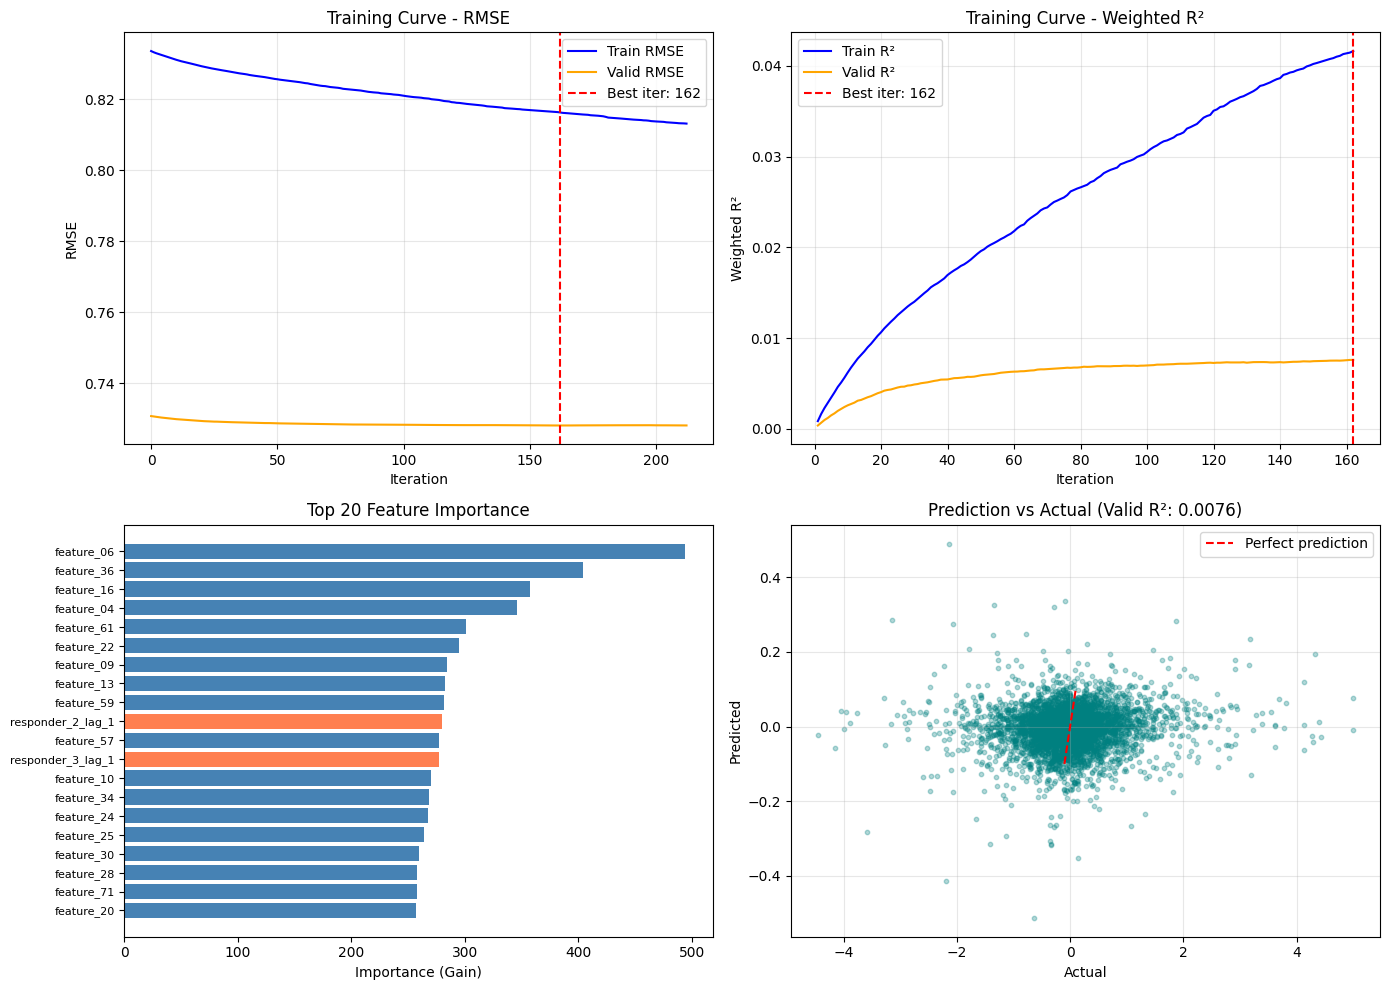


Model saved to 'xgb_model_small.json'
Feature importance saved to 'xgb_feature_importance.csv'

TRAINING SUMMARY
Total features:        68
Training samples:      21,022,056
Validation samples:    1,082,224
Best iteration:        162
Training time:         438.03s
Train Weighted R²:     0.041614
Valid Weighted R²:     0.007618
XGBOOST TRAINING - LARGER CONFIGURATION
Started at: 2025-12-05 07:27:15

Total features: 68
  - Original features: 59
  - Lag features: 9

----------------------------------------------------------------------
COLLECTING DATA
----------------------------------------------------------------------

  Completed in 8.32s
  X_train shape: (21022056, 68)
  Memory: ~5.72 GB

  Completed in 4.35s
  X_valid shape: (1082224, 68)

Creating XGBoost DMatrices...

TRAINING CONFIGURATION

Hyperparameters:
  objective: reg:squarederror
  eval_metric: rmse
  booster: gbtree
  learning_rate: 0.02
  max_depth: 12
  min_child_weight: 10
  subsample: 0.7
  colsample_bytree: 0.7
  col

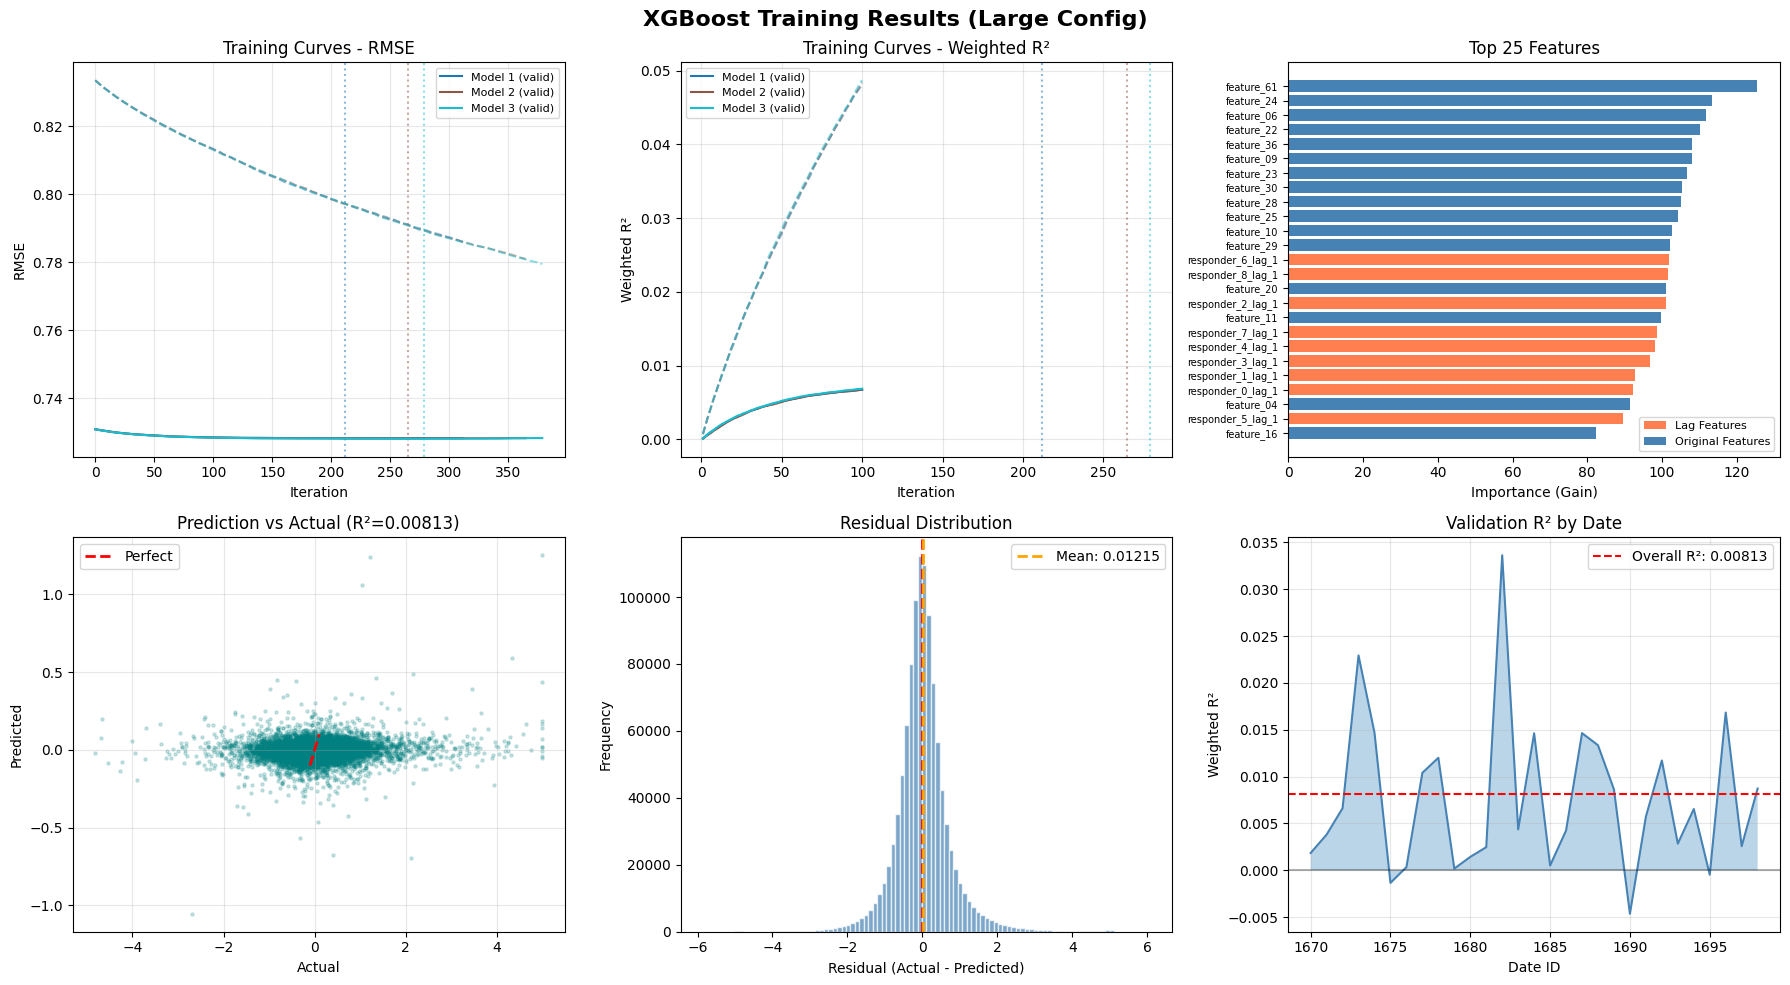


SAVING MODELS
  Saved: xgb_models/xgb_model_seed42.json
  Saved: xgb_models/xgb_model_seed123.json
  Saved: xgb_models/xgb_model_seed456.json
  Saved: xgb_models/feature_importance.csv
  Saved: xgb_models/config.json

TRAINING SUMMARY

  Configuration:        LARGE (XGBoost)
  Ensemble:             True (3 models)
  Total features:       68
  Training samples:     21,022,056
  Validation samples:   1,082,224

  Hyperparameters:
    - max_depth:        12
    - learning_rate:    0.02
    - num_boost_round:  3000

  Best iterations:      [212, 265, 279]
  Training time:        2801.03s (46.68 min)

  FINAL SCORES:
    - Train Weighted R²:  0.097114
    - Valid Weighted R²:  0.008133
    - Train RMSE:         0.792331
    - Valid RMSE:         0.727972

Completed at: 2025-12-05 08:22:34


15116

In [3]:
# -*- coding: utf-8 -*-
"""math5470_final project.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1ImQyLtBPI-swAiwTeWOtfOivZWik4awT
"""

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import polars as pl
import numpy as np
import gc
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import StratifiedGroupKFold

class CONFIG:
    target_col = "responder_6"
    lag_cols_original = ["date_id", "symbol_id"] + [f"responder_{idx}" for idx in range(9)]
    lag_cols_rename = {f"responder_{idx}": f"responder_{idx}_lag_1" for idx in range(9)}
    valid_ratio = 0.05
    start_dt = 1100

# ============================================
# Features to remove (high missing rate / high correlation)
# ============================================
Features_to_remove = [
    'feature_42', 'feature_39', 'feature_53', 'feature_50', 'feature_15',
    'feature_44', 'feature_41', 'feature_55', 'feature_52', 'feature_08',
    'feature_74', 'feature_73', 'feature_58', 'feature_33', 'feature_32',
    'feature_31', 'feature_27', 'feature_26', 'feature_21', 'feature_17'
]
# Remove duplicates from the list
Features_to_remove = list(set(Features_to_remove))

# ============================================
# Load data with lazy evaluation
# ============================================
train = pl.scan_parquet(
    f"/content/drive/MyDrive/MATH 5470 fall 2025/jane-street-real-time-market-data-forecasting/train.parquet/**/part-*.parquet"
).select(
    pl.int_range(pl.len(), dtype=pl.UInt32).alias("id"),
    pl.all(),
).with_columns(
    (pl.col(CONFIG.target_col) * 2).cast(pl.Int32).alias("label"),
).filter(
    pl.col("date_id").gt(CONFIG.start_dt)
)

# ============================================
# Remove specified features
# ============================================
# Get all columns first to check which features exist
all_columns = train.collect_schema().names()
features_to_drop = [f for f in Features_to_remove if f in all_columns]

print(f"Features to remove: {len(features_to_drop)}")
print(f"Features being dropped: {features_to_drop}")

train = train.drop(features_to_drop)

# Get remaining feature columns
remaining_columns = train.collect_schema().names()
feature_cols = [c for c in remaining_columns if c.startswith("feature_")]
print(f"Number of features after removal: {len(feature_cols)}")
print(f"Remaining feature columns: {feature_cols}")

# ============================================
# Compute mean values for imputation (on training data sample)
# ============================================
print("\nComputing mean values for imputation...")

# Sample data to compute means efficiently
mean_df = train.filter(
    pl.col("date_id").le(1400)  # Use earlier data for computing means
).select(feature_cols).collect(streaming=True)

# Compute means for each feature column
feature_means = {}
for col in feature_cols:
    mean_val = mean_df[col].mean()
    feature_means[col] = float(mean_val) if mean_val is not None else 0.0

print(f"Computed means for {len(feature_means)} features")

# Clean up
del mean_df
gc.collect()

# ============================================
# Also compute means for lag columns (will use 0 since they're responders)
# ============================================
lag_feature_names = [f"responder_{idx}_lag_1" for idx in range(9)]

# ============================================
# Create lag features
# ============================================
lags = train.select(pl.col(CONFIG.lag_cols_original))
lags = lags.rename(CONFIG.lag_cols_rename)
lags = lags.with_columns(
    date_id=pl.col('date_id') + 1,  # lagged by 1 day
)
lags = lags.group_by(["date_id", "symbol_id"], maintain_order=True).last()

# Join lags to train
train = train.join(lags, on=["date_id", "symbol_id"], how="left")

# ============================================
# Apply mean imputation to feature columns
# ============================================
# Build imputation expressions for feature columns
impute_expressions = []
for col in feature_cols:
    impute_expressions.append(
        pl.col(col).fill_null(feature_means[col])
    )

# Impute lag columns with 0 (no previous day data available)
for col in lag_feature_names:
    impute_expressions.append(
        pl.col(col).fill_null(0.0)
    )

train = train.with_columns(impute_expressions)

# ============================================
# Train/Validation split
# ============================================
len_train = train.select(pl.col("date_id")).collect().shape[0]
valid_records = int(len_train * CONFIG.valid_ratio)
len_ofl_mdl = len_train - valid_records
last_tr_dt = train.select(pl.col("date_id")).collect().row(len_ofl_mdl)[0]

print(f"\nlen_train = {len_train}")
print(f"len_ofl_mdl = {len_ofl_mdl}")
print(f"---> Last offline train date = {last_tr_dt}\n")

training_data = train.filter(pl.col("date_id").le(last_tr_dt))
validation_data = train.filter(pl.col("date_id").gt(last_tr_dt))

# ============================================
# Verify no missing values in features
# ============================================
print("Verifying imputation...")
sample_check = training_data.select(feature_cols).head(10000).collect()
null_counts = sample_check.null_count()
total_nulls = sum(null_counts.row(0))
print(f"Total nulls in feature columns (sample): {total_nulls}")

# ============================================
# Save feature means for inference
# ============================================
np.save('feature_means.npy', feature_means)
print(f"\nFeature means saved to 'feature_means.npy'")

# ============================================
# Summary
# ============================================
print("\n" + "="*50)
print("PREPROCESSING SUMMARY")
print("="*50)
print(f"Original features: 79")
print(f"Features removed: {len(features_to_drop)}")
print(f"Remaining features: {len(feature_cols)}")
print(f"Lag features added: {len(lag_feature_names)}")
print(f"Total features for training: {len(feature_cols) + len(lag_feature_names)}")
print(f"Training samples: ~{len_ofl_mdl:,}")
print(f"Validation samples: ~{valid_records:,}")
print("="*50)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ============================================
# VISUALIZATIONS
# ============================================

# Collect a sample of data for visualization (to avoid memory issues)
print("Collecting sample data for visualization...")
viz_sample = training_data.select(
    feature_cols + lag_feature_names + [CONFIG.target_col, "date_id", "symbol_id", "weight"]
).head(100000).collect()

print(f"Visualization sample size: {viz_sample.shape[0]:,} rows")

# Convert to pandas for easier plotting
viz_df = viz_sample.to_pandas()

# ============================================
# PLOT 1: Feature Distributions (Selected Features)
# ============================================
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Distribution of Selected Features', fontsize=16, fontweight='bold')

# Select 12 random features to visualize
np.random.seed(42)
selected_features = np.random.choice(feature_cols, size=min(12, len(feature_cols)), replace=False)

for idx, feature in enumerate(selected_features):
    ax = axes[idx // 4, idx % 4]
    data = viz_df[feature].dropna()

    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {data.median():.3f}')

    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# PLOT 2: Correlation Heatmap (Top Features)
# ============================================
fig, ax = plt.subplots(figsize=(14, 12))

# Select subset of features for correlation (too many features = unreadable heatmap)
corr_features = feature_cols[:20] + [CONFIG.target_col]  # First 20 features + target
corr_matrix = viz_df[corr_features].corr()

# Create heatmap
cmap = plt.cm.RdBu_r
im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation', fontsize=12)

# Set ticks
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_features, fontsize=8)

# Add correlation values as text
for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

ax.set_title('Feature Correlation Heatmap (First 20 Features + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# PLOT 3: Target Distribution & Feature-Target Relationships
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3a: Target distribution
ax1 = axes[0, 0]
target_data = viz_df[CONFIG.target_col].dropna()
ax1.hist(target_data, bins=100, color='coral', edgecolor='white', alpha=0.7)
ax1.axvline(target_data.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {target_data.mean():.4f}')
ax1.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_title(f'Target Distribution ({CONFIG.target_col})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Target Value', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.legend()

# 3b: Target by date (rolling mean)
ax2 = axes[0, 1]
date_target = viz_df.groupby('date_id')[CONFIG.target_col].agg(['mean', 'std']).reset_index()
ax2.plot(date_target['date_id'], date_target['mean'], color='steelblue', linewidth=1.5, label='Mean')
ax2.fill_between(date_target['date_id'],
                  date_target['mean'] - date_target['std'],
                  date_target['mean'] + date_target['std'],
                  alpha=0.3, color='steelblue', label='±1 Std')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_title('Target Mean by Date', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date ID', fontsize=10)
ax2.set_ylabel('Mean Target', fontsize=10)
ax2.legend()

# 3c: Feature vs Target scatter (select important feature)
ax3 = axes[1, 0]
# Find feature with highest absolute correlation to target
correlations = viz_df[feature_cols].corrwith(viz_df[CONFIG.target_col]).abs()
top_feature = correlations.idxmax()
top_corr = correlations.max()

# Sample for scatter plot
scatter_sample = viz_df[[top_feature, CONFIG.target_col]].dropna().sample(min(5000, len(viz_df)))
ax3.scatter(scatter_sample[top_feature], scatter_sample[CONFIG.target_col],
            alpha=0.3, s=10, c='teal')
ax3.axhline(0, color='red', linestyle='--', alpha=0.5)
ax3.axvline(0, color='red', linestyle='--', alpha=0.5)
ax3.set_title(f'Top Correlated Feature vs Target\n{top_feature} (r={top_corr:.3f})',
              fontsize=12, fontweight='bold')
ax3.set_xlabel(top_feature, fontsize=10)
ax3.set_ylabel(CONFIG.target_col, fontsize=10)

# 3d: Lag features correlation with target
ax4 = axes[1, 1]
lag_corrs = viz_df[lag_feature_names].corrwith(viz_df[CONFIG.target_col])
colors = ['green' if c > 0 else 'red' for c in lag_corrs]
bars = ax4.barh(range(len(lag_feature_names)), lag_corrs, color=colors, alpha=0.7)
ax4.set_yticks(range(len(lag_feature_names)))
ax4.set_yticklabels(lag_feature_names, fontsize=9)
ax4.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Lag Features Correlation with Target', fontsize=12, fontweight='bold')
ax4.set_xlabel('Correlation', fontsize=10)

# Add correlation values on bars
for i, (bar, corr) in enumerate(zip(bars, lag_corrs)):
    ax4.text(corr + 0.01 if corr >= 0 else corr - 0.01,
             i, f'{corr:.3f}', va='center',
             ha='left' if corr >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# PLOT 4 (Bonus): Missing Values Overview (Before Imputation)
# ============================================
# This shows what features had the most missing values originally
print("\n" + "="*50)
print("VISUALIZATION SUMMARY")
print("="*50)
print("1. feature_distributions.png - Distribution of 12 random features")
print("2. correlation_heatmap.png - Correlation matrix of top 20 features")
print("3. target_analysis.png - Target distribution and feature relationships")
print("="*50)

# Clean up
del viz_sample, viz_df
gc.collect()

import xgboost as xgb
import numpy as np
import polars as pl
import gc
import time
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt

# ============================================
# XGBOOST CONFIGURATION
# ============================================
class XGB_CONFIG:
    # XGBoost configuration
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': 'gbtree',
        'learning_rate': 0.05,           # eta
        'max_depth': 8,                  # Shallow trees
        'min_child_weight': 100,         # Similar to min_child_samples in LGBM
        'subsample': 0.6,                # Similar to bagging_fraction
        'colsample_bytree': 0.6,         # Similar to feature_fraction
        'colsample_bylevel': 0.6,
        'alpha': 0.1,                    # L1 regularization
        'lambda': 0.1,                   # L2 regularization
        'seed': 42,
        'nthread': -1,
        'verbosity': 0,
    }

    num_boost_round = 500
    early_stopping_rounds = 50
    verbose_eval = 50

# ============================================
# PREPARE FEATURE COLUMNS
# ============================================
print("="*60)
print("PREPARING DATA FOR XGBOOST")
print("="*60)

# Define feature columns (from preprocessing)
feature_cols = [c for c in training_data.collect_schema().names() if c.startswith("feature_")]
lag_feature_names = [f"responder_{idx}_lag_1" for idx in range(9)]

# All features for training
all_features = feature_cols + lag_feature_names

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Number of lag features: {len(lag_feature_names)}")
print(f"Total features: {len(all_features)}")

# ============================================
# COLLECT DATA
# ============================================
print("\nCollecting training data...")
start_time = time.time()

# Collect training data
train_collected = training_data.select(
    all_features + [CONFIG.target_col, "weight"]
).collect()

X_train = train_collected.select(all_features).to_numpy()
y_train = train_collected.select(CONFIG.target_col).to_numpy().flatten()
w_train = train_collected.select("weight").to_numpy().flatten()

print(f"Training data collected in {time.time() - start_time:.2f}s")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Collect validation data
print("\nCollecting validation data...")
start_time = time.time()

valid_collected = validation_data.select(
    all_features + [CONFIG.target_col, "weight"]
).collect()

X_valid = valid_collected.select(all_features).to_numpy()
y_valid = valid_collected.select(CONFIG.target_col).to_numpy().flatten()
w_valid = valid_collected.select("weight").to_numpy().flatten()

print(f"Validation data collected in {time.time() - start_time:.2f}s")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")

# Clean up polars dataframes
del train_collected, valid_collected
gc.collect()

# ============================================
# CREATE XGBOOST DMATRICES
# ============================================
print("\nCreating XGBoost DMatrices...")

# Create DMatrix for training with weights
dtrain = xgb.DMatrix(
    X_train,
    label=y_train,
    weight=w_train,
    feature_names=all_features
)

dvalid = xgb.DMatrix(
    X_valid,
    label=y_valid,
    weight=w_valid,
    feature_names=all_features
)

# ============================================
# CUSTOM WEIGHTED R² METRIC (Jane Street Metric)
# ============================================
def weighted_r2_score(y_true, y_pred, weights):
    """Calculate weighted R² score."""
    numerator = np.sum(weights * (y_true - y_pred) ** 2)
    denominator = np.sum(weights * (y_true - np.average(y_true, weights=weights)) ** 2)
    return 1 - (numerator / denominator) if denominator != 0 else 0

def xgb_weighted_r2(preds, dtrain):
    """Custom XGBoost evaluation metric."""
    y_true = dtrain.get_label()
    weights = dtrain.get_weight()
    if weights is None:
        weights = np.ones_like(y_true)
    score = weighted_r2_score(y_true, preds, weights)
    return 'weighted_r2', score

# ============================================
# TRAIN MODEL
# ============================================
print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)
print(f"\nParameters:")
for key, value in XGB_CONFIG.params.items():
    print(f"  {key}: {value}")
print(f"\nnum_boost_round: {XGB_CONFIG.num_boost_round}")
print(f"early_stopping_rounds: {XGB_CONFIG.early_stopping_rounds}")
print("\n")

# Store evaluation results
evals_result = {}

start_time = time.time()

model = xgb.train(
    params=XGB_CONFIG.params,
    dtrain=dtrain,
    num_boost_round=XGB_CONFIG.num_boost_round,
    evals=[(dtrain, 'train'), (dvalid, 'valid')],
    early_stopping_rounds=XGB_CONFIG.early_stopping_rounds,
    verbose_eval=XGB_CONFIG.verbose_eval,
    evals_result=evals_result,
    custom_metric=xgb_weighted_r2,
    maximize=True  # Since R² is higher is better
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f}s ({training_time/60:.2f} min)")

# ============================================
# EVALUATE MODEL
# ============================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Best iteration
print(f"\nBest iteration: {model.best_iteration}")

# Predictions
y_train_pred = model.predict(dtrain, iteration_range=(0, model.best_iteration))
y_valid_pred = model.predict(dvalid, iteration_range=(0, model.best_iteration))

# Calculate metrics
train_r2 = weighted_r2_score(y_train, y_train_pred, w_train)
valid_r2 = weighted_r2_score(y_valid, y_valid_pred, w_valid)

train_rmse = np.sqrt(np.average((y_train - y_train_pred)**2, weights=w_train))
valid_rmse = np.sqrt(np.average((y_valid - y_valid_pred)**2, weights=w_valid))

print(f"\nWeighted R² Score:")
print(f"  Training:   {train_r2:.6f}")
print(f"  Validation: {valid_r2:.6f}")

print(f"\nWeighted RMSE:")
print(f"  Training:   {train_rmse:.6f}")
print(f"  Validation: {valid_rmse:.6f}")

# ============================================
# FEATURE IMPORTANCE
# ============================================
print("\n" + "="*60)
print("TOP 20 FEATURE IMPORTANCE")
print("="*60)

# Get feature importance
importance_dict = model.get_score(importance_type='gain')
importance_df = pl.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort('importance', descending=True)

print("\n")
for i, row in enumerate(importance_df.head(20).iter_rows()):
    print(f"  {i+1:2}. {row[0]:25} : {row[1]:,.0f}")

# ============================================
# VISUALIZATION
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training curves - RMSE
ax1 = axes[0, 0]
ax1.plot(evals_result['train']['rmse'], label='Train RMSE', color='blue')
ax1.plot(evals_result['valid']['rmse'], label='Valid RMSE', color='orange')
ax1.axvline(model.best_iteration, color='red', linestyle='--', label=f'Best iter: {model.best_iteration}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('RMSE')
ax1.set_title('Training Curve - RMSE')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Training curves - Weighted R²
ax2 = axes[0, 1]
train_r2_vals = []
valid_r2_vals = []

# Calculate R² for each iteration
for i in range(1, model.best_iteration + 1):
    train_pred = model.predict(dtrain, iteration_range=(0, i))
    valid_pred = model.predict(dvalid, iteration_range=(0, i))
    train_r2_vals.append(weighted_r2_score(y_train, train_pred, w_train))
    valid_r2_vals.append(weighted_r2_score(y_valid, valid_pred, w_valid))

ax2.plot(range(1, model.best_iteration + 1), train_r2_vals, label='Train R²', color='blue')
ax2.plot(range(1, model.best_iteration + 1), valid_r2_vals, label='Valid R²', color='orange')
ax2.axvline(model.best_iteration, color='red', linestyle='--', label=f'Best iter: {model.best_iteration}')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Weighted R²')
ax2.set_title('Training Curve - Weighted R²')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Feature importance (top 20)
ax3 = axes[1, 0]
top_20 = importance_df.head(20)
colors = ['coral' if 'lag' in f else 'steelblue' for f in top_20['feature'].to_list()]
ax3.barh(range(20), top_20['importance'].to_list(), color=colors)
ax3.set_yticks(range(20))
ax3.set_yticklabels(top_20['feature'].to_list(), fontsize=8)
ax3.invert_yaxis()
ax3.set_xlabel('Importance (Gain)')
ax3.set_title('Top 20 Feature Importance')

# 4. Prediction vs Actual (validation set sample)
ax4 = axes[1, 1]
sample_idx = np.random.choice(len(y_valid), size=min(5000, len(y_valid)), replace=False)
ax4.scatter(y_valid[sample_idx], y_valid_pred[sample_idx], alpha=0.3, s=10, c='teal')
ax4.plot([-0.1, 0.1], [-0.1, 0.1], 'r--', label='Perfect prediction')
ax4.set_xlabel('Actual')
ax4.set_ylabel('Predicted')
ax4.set_title(f'Prediction vs Actual (Valid R²: {valid_r2:.4f})')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# SAVE MODEL
# ============================================
model.save_model('xgb_model_small.json')
print("\nModel saved to 'xgb_model_small.json'")

# Save feature importance
importance_df.write_csv('xgb_feature_importance.csv')
print("Feature importance saved to 'xgb_feature_importance.csv'")

# ============================================
# SUMMARY
# ============================================
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total features:        {len(all_features)}")
print(f"Training samples:      {X_train.shape[0]:,}")
print(f"Validation samples:    {X_valid.shape[0]:,}")
print(f"Best iteration:        {model.best_iteration}")
print(f"Training time:         {training_time:.2f}s")
print(f"Train Weighted R²:     {train_r2:.6f}")
print(f"Valid Weighted R²:     {valid_r2:.6f}")
print("="*60)

# Clean up
del X_train, y_train, w_train, X_valid, y_valid, w_valid, dtrain, dvalid
gc.collect()

"""## XGBOOST version 2 (larger configuration)"""

import xgboost as xgb
import numpy as np
import polars as pl
import gc
import time
from datetime import datetime
import matplotlib.pyplot as plt
import json
import os

# ============================================
# LARGER XGBOOST CONFIGURATION
# ============================================
class XGB_CONFIG:
    # Larger configuration for better performance
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': 'gbtree',
        'learning_rate': 0.02,           # Lower LR for more trees
        'max_depth': 12,                 # Deeper trees
        'min_child_weight': 10,          # Less restrictive
        'subsample': 0.7,                # Use 70% of data
        'colsample_bytree': 0.7,         # Use 70% of features
        'colsample_bylevel': 0.7,
        'colsample_bynode': 0.7,
        'alpha': 0.05,                   # L1 regularization
        'lambda': 0.05,                  # L2 regularization
        'gamma': 0.0,                    # Minimum loss reduction
        'max_bin': 256,                  # Number of bins
        'seed': 42,
        'nthread': -1,
        'verbosity': 0,
        # 'tree_method': 'gpu_hist',     # Uncomment for GPU training
        # 'gpu_id': 0,
    }

    num_boost_round = 3000               # More trees
    early_stopping_rounds = 100          # More patience
    verbose_eval = 100

    # Multiple seeds for ensemble (optional)
    seeds = [42, 123, 456]
    use_ensemble = True                  # Set to False for single model

# ============================================
# PREPARE FEATURE COLUMNS
# ============================================
print("="*70)
print("XGBOOST TRAINING - LARGER CONFIGURATION")
print("="*70)
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Define feature columns
feature_cols = [c for c in training_data.collect_schema().names() if c.startswith("feature_")]
lag_feature_names = [f"responder_{idx}_lag_1" for idx in range(9)]
all_features = feature_cols + lag_feature_names

print(f"\nTotal features: {len(all_features)}")
print(f"  - Original features: {len(feature_cols)}")
print(f"  - Lag features: {len(lag_feature_names)}")

# ============================================
# COLLECT DATA
# ============================================
print("\n" + "-"*70)
print("COLLECTING DATA")
print("-"*70)

# Collect training data
print("\nCollecting training data...")
start_time = time.time()

train_collected = training_data.select(
    all_features + [CONFIG.target_col, "weight", "date_id", "symbol_id"]
).collect()

X_train = train_collected.select(all_features).to_numpy().astype(np.float32)
y_train = train_collected.select(CONFIG.target_col).to_numpy().flatten().astype(np.float32)
w_train = train_collected.select("weight").to_numpy().flatten().astype(np.float32)
date_train = train_collected.select("date_id").to_numpy().flatten()

print(f"  Completed in {time.time() - start_time:.2f}s")
print(f"  X_train shape: {X_train.shape}")
print(f"  Memory: ~{X_train.nbytes / 1e9:.2f} GB")

# Collect validation data
print("\nCollecting validation data...")
start_time = time.time()

valid_collected = validation_data.select(
    all_features + [CONFIG.target_col, "weight", "date_id", "symbol_id"]
).collect()

X_valid = valid_collected.select(all_features).to_numpy().astype(np.float32)
y_valid = valid_collected.select(CONFIG.target_col).to_numpy().flatten().astype(np.float32)
w_valid = valid_collected.select("weight").to_numpy().flatten().astype(np.float32)
date_valid = valid_collected.select("date_id").to_numpy().flatten()

print(f"  Completed in {time.time() - start_time:.2f}s")
print(f"  X_valid shape: {X_valid.shape}")

# Clean up
del train_collected, valid_collected
gc.collect()

# ============================================
# CREATE XGBOOST DMATRICES
# ============================================
print("\nCreating XGBoost DMatrices...")

dtrain = xgb.DMatrix(
    X_train,
    label=y_train,
    weight=w_train,
    feature_names=all_features
)

dvalid = xgb.DMatrix(
    X_valid,
    label=y_valid,
    weight=w_valid,
    feature_names=all_features
)

# ============================================
# CUSTOM METRICS
# ============================================
def weighted_r2_score(y_true, y_pred, weights):
    """Calculate weighted R² score (competition metric)."""
    numerator = np.sum(weights * (y_true - y_pred) ** 2)
    denominator = np.sum(weights * (y_true - np.average(y_true, weights=weights)) ** 2)
    return 1 - (numerator / denominator) if denominator != 0 else 0

def xgb_weighted_r2(preds, dtrain):
    """Custom XGBoost evaluation metric."""
    y_true = dtrain.get_label()
    weights = dtrain.get_weight()
    if weights is None:
        weights = np.ones_like(y_true)
    score = weighted_r2_score(y_true, preds, weights)
    return 'weighted_r2', score

# ============================================
# TRAINING FUNCTION
# ============================================
def train_single_model(seed, train_dmatrix, valid_dmatrix, config):
    """Train a single XGBoost model with given seed."""

    params = config.params.copy()
    params['seed'] = seed
    params['random_state'] = seed

    evals_result = {}

    model = xgb.train(
        params=params,
        dtrain=train_dmatrix,
        num_boost_round=config.num_boost_round,
        evals=[(train_dmatrix, 'train'), (valid_dmatrix, 'valid')],
        early_stopping_rounds=config.early_stopping_rounds,
        verbose_eval=config.verbose_eval,
        evals_result=evals_result,
        custom_metric=xgb_weighted_r2,
        maximize=True
    )

    return model, evals_result

# ============================================
# TRAIN MODEL(S)
# ============================================
print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"\nHyperparameters:")
for key, value in XGB_CONFIG.params.items():
    print(f"  {key}: {value}")
print(f"\nnum_boost_round: {XGB_CONFIG.num_boost_round}")
print(f"early_stopping_rounds: {XGB_CONFIG.early_stopping_rounds}")

if XGB_CONFIG.use_ensemble:
    print(f"\nTraining ensemble with {len(XGB_CONFIG.seeds)} seeds: {XGB_CONFIG.seeds}")
else:
    print(f"\nTraining single model with seed: {XGB_CONFIG.seeds[0]}")

models = []
all_evals_results = []
total_start_time = time.time()

seeds_to_use = XGB_CONFIG.seeds if XGB_CONFIG.use_ensemble else [XGB_CONFIG.seeds[0]]

for i, seed in enumerate(seeds_to_use):
    print("\n" + "="*70)
    print(f"TRAINING MODEL {i+1}/{len(seeds_to_use)} (seed={seed})")
    print("="*70 + "\n")

    model_start_time = time.time()

    model, evals_result = train_single_model(
        seed=seed,
        train_dmatrix=dtrain,
        valid_dmatrix=dvalid,
        config=XGB_CONFIG
    )

    model_time = time.time() - model_start_time

    models.append(model)
    all_evals_results.append(evals_result)

    print(f"\nModel {i+1} completed in {model_time:.2f}s ({model_time/60:.2f} min)")
    print(f"Best iteration: {model.best_iteration}")

total_training_time = time.time() - total_start_time
print(f"\n{'='*70}")
print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} min)")
print(f"{'='*70}")

# ============================================
# PREDICTIONS & EVALUATION
# ============================================
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Generate predictions
if XGB_CONFIG.use_ensemble:
    # Ensemble predictions (average)
    print("\nGenerating ensemble predictions...")
    y_train_preds = np.zeros((len(models), len(y_train)))
    y_valid_preds = np.zeros((len(models), len(y_valid)))

    for i, model in enumerate(models):
        y_train_preds[i] = model.predict(dtrain, iteration_range=(0, model.best_iteration))
        y_valid_preds[i] = model.predict(dvalid, iteration_range=(0, model.best_iteration))

    y_train_pred = np.mean(y_train_preds, axis=0)
    y_valid_pred = np.mean(y_valid_preds, axis=0)

    # Individual model scores
    print("\nIndividual Model Scores:")
    print("-"*50)
    for i, model in enumerate(models):
        train_r2_i = weighted_r2_score(y_train, y_train_preds[i], w_train)
        valid_r2_i = weighted_r2_score(y_valid, y_valid_preds[i], w_valid)
        print(f"  Model {i+1} (seed={XGB_CONFIG.seeds[i]}): Train R²={train_r2_i:.6f}, Valid R²={valid_r2_i:.6f}")
else:
    print("\nGenerating predictions...")
    y_train_pred = models[0].predict(dtrain, iteration_range=(0, models[0].best_iteration))
    y_valid_pred = models[0].predict(dvalid, iteration_range=(0, models[0].best_iteration))

# Calculate final metrics
train_r2 = weighted_r2_score(y_train, y_train_pred, w_train)
valid_r2 = weighted_r2_score(y_valid, y_valid_pred, w_valid)

train_rmse = np.sqrt(np.average((y_train - y_train_pred)**2, weights=w_train))
valid_rmse = np.sqrt(np.average((y_valid - y_valid_pred)**2, weights=w_valid))

print("\n" + "-"*50)
print("FINAL SCORES" + (" (Ensemble)" if XGB_CONFIG.use_ensemble else ""))
print("-"*50)
print(f"\nWeighted R² Score:")
print(f"  Training:   {train_r2:.6f}")
print(f"  Validation: {valid_r2:.6f}")

print(f"\nWeighted RMSE:")
print(f"  Training:   {train_rmse:.6f}")
print(f"  Validation: {valid_rmse:.6f}")

# Score by date
print("\n" + "-"*50)
print("VALIDATION R² BY DATE (sample)")
print("-"*50)
unique_dates = np.unique(date_valid)
sample_dates = unique_dates[::max(1, len(unique_dates)//10)]  # Sample 10 dates

for date in sample_dates[:10]:
    mask = date_valid == date
    if np.sum(mask) > 0:
        date_r2 = weighted_r2_score(y_valid[mask], y_valid_pred[mask], w_valid[mask])
        print(f"  Date {int(date)}: R²={date_r2:.6f} (n={np.sum(mask):,})")

# ============================================
# FEATURE IMPORTANCE (Averaged across models)
# ============================================
print("\n" + "="*70)
print("TOP 25 FEATURE IMPORTANCE (Gain)")
print("="*70)

# Get importance from all models and average
all_importances = []
for model in models:
    importance_dict = model.get_score(importance_type='gain')
    # Create array for all features
    importance_array = np.zeros(len(all_features))
    for idx, feature in enumerate(all_features):
        importance_array[idx] = importance_dict.get(feature, 0)
    all_importances.append(importance_array)

avg_importance = np.mean(all_importances, axis=0)

importance_df = pl.DataFrame({
    'feature': all_features,
    'importance_gain': avg_importance,
}).sort('importance_gain', descending=True)

print("\n")
for i, row in enumerate(importance_df.head(25).iter_rows()):
    feature_type = "LAG" if "lag" in row[0] else "   "
    print(f"  {i+1:2}. [{feature_type}] {row[0]:30} : Gain={row[1]:>12,.0f}")

# ============================================
# VISUALIZATION
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('XGBoost Training Results (Large Config)', fontsize=16, fontweight='bold')

# 1. Training curves - RMSE (all models)
ax1 = axes[0, 0]
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
for i, (model, evals_result) in enumerate(zip(models, all_evals_results)):
    ax1.plot(evals_result['train']['rmse'], color=colors[i], alpha=0.5, linestyle='--')
    ax1.plot(evals_result['valid']['rmse'], color=colors[i], label=f'Model {i+1} (valid)')
    ax1.axvline(model.best_iteration, color=colors[i], linestyle=':', alpha=0.5)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('RMSE')
ax1.set_title('Training Curves - RMSE')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Training curves - Weighted R²
ax2 = axes[0, 1]
# Calculate R² for each iteration for all models
for i, model in enumerate(models):
    train_r2_vals = []
    valid_r2_vals = []
    for j in range(1, min(100, model.best_iteration) + 1):  # Limit to 100 iterations for speed
        train_pred = model.predict(dtrain, iteration_range=(0, j))
        valid_pred = model.predict(dvalid, iteration_range=(0, j))
        train_r2_vals.append(weighted_r2_score(y_train, train_pred, w_train))
        valid_r2_vals.append(weighted_r2_score(y_valid, valid_pred, w_valid))

    ax2.plot(range(1, len(train_r2_vals) + 1), train_r2_vals, color=colors[i], alpha=0.5, linestyle='--')
    ax2.plot(range(1, len(valid_r2_vals) + 1), valid_r2_vals, color=colors[i], label=f'Model {i+1} (valid)')
    ax2.axvline(model.best_iteration, color=colors[i], linestyle=':', alpha=0.5)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Weighted R²')
ax2.set_title('Training Curves - Weighted R²')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Feature importance (top 25)
ax3 = axes[0, 2]
top_25 = importance_df.head(25)
colors_bar = ['coral' if 'lag' in f else 'steelblue' for f in top_25['feature'].to_list()]
bars = ax3.barh(range(25), top_25['importance_gain'].to_list(), color=colors_bar)
ax3.set_yticks(range(25))
ax3.set_yticklabels(top_25['feature'].to_list(), fontsize=7)
ax3.invert_yaxis()
ax3.set_xlabel('Importance (Gain)')
ax3.set_title('Top 25 Features')
ax3.legend([plt.Rectangle((0,0),1,1,fc='coral'), plt.Rectangle((0,0),1,1,fc='steelblue')],
           ['Lag Features', 'Original Features'], loc='lower right', fontsize=8)

# 4. Prediction vs Actual
ax4 = axes[1, 0]
sample_idx = np.random.choice(len(y_valid), size=min(10000, len(y_valid)), replace=False)
ax4.scatter(y_valid[sample_idx], y_valid_pred[sample_idx], alpha=0.2, s=5, c='teal')
ax4.plot([-0.1, 0.1], [-0.1, 0.1], 'r--', linewidth=2, label='Perfect')
ax4.set_xlabel('Actual')
ax4.set_ylabel('Predicted')
ax4.set_title(f'Prediction vs Actual (R²={valid_r2:.5f})')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Residual distribution
ax5 = axes[1, 1]
residuals = y_valid - y_valid_pred
ax5.hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
ax5.axvline(0, color='red', linestyle='--', linewidth=2)
ax5.axvline(np.mean(residuals), color='orange', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(residuals):.5f}')
ax5.set_xlabel('Residual (Actual - Predicted)')
ax5.set_ylabel('Frequency')
ax5.set_title('Residual Distribution')
ax5.legend()

# 6. R² by date
ax6 = axes[1, 2]
date_r2_scores = []
for date in unique_dates:
    mask = date_valid == date
    if np.sum(mask) > 10:
        r2 = weighted_r2_score(y_valid[mask], y_valid_pred[mask], w_valid[mask])
        date_r2_scores.append((date, r2))

dates = [d[0] for d in date_r2_scores]
r2_scores = [d[1] for d in date_r2_scores]
ax6.plot(dates, r2_scores, color='steelblue', linewidth=1.5)
ax6.axhline(valid_r2, color='red', linestyle='--', label=f'Overall R²: {valid_r2:.5f}')
ax6.axhline(0, color='black', linestyle='-', alpha=0.3)
ax6.fill_between(dates, r2_scores, alpha=0.3)
ax6.set_xlabel('Date ID')
ax6.set_ylabel('Weighted R²')
ax6.set_title('Validation R² by Date')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_training_results_large.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# SAVE MODELS
# ============================================
print("\n" + "="*70)
print("SAVING MODELS")
print("="*70)

# Create output directory
os.makedirs('xgb_models', exist_ok=True)

# Save each model
for i, model in enumerate(models):
    model_path = f'xgb_models/xgb_model_seed{XGB_CONFIG.seeds[i]}.json'
    model.save_model(model_path)
    print(f"  Saved: {model_path}")

# Save feature importance
importance_df.write_csv('xgb_models/feature_importance.csv')
print("  Saved: xgb_models/feature_importance.csv")

# Save configuration
config_dict = {
    'params': XGB_CONFIG.params,
    'num_boost_round': XGB_CONFIG.num_boost_round,
    'early_stopping_rounds': XGB_CONFIG.early_stopping_rounds,
    'seeds': XGB_CONFIG.seeds,
    'use_ensemble': XGB_CONFIG.use_ensemble,
    'best_iterations': [m.best_iteration for m in models],
    'train_r2': float(train_r2),
    'valid_r2': float(valid_r2),
    'train_rmse': float(train_rmse),
    'valid_rmse': float(valid_rmse),
    'n_features': len(all_features),
    'training_time_seconds': total_training_time,
}

with open('xgb_models/config.json', 'w') as f:
    json.dump(config_dict, f, indent=2)
print("  Saved: xgb_models/config.json")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"""
  Configuration:        LARGE (XGBoost)
  Ensemble:             {XGB_CONFIG.use_ensemble} ({len(models)} models)
  Total features:       {len(all_features)}
  Training samples:     {X_train.shape[0]:,}
  Validation samples:   {X_valid.shape[0]:,}

  Hyperparameters:
    - max_depth:        {XGB_CONFIG.params['max_depth']}
    - learning_rate:    {XGB_CONFIG.params['learning_rate']}
    - num_boost_round:  {XGB_CONFIG.num_boost_round}

  Best iterations:      {[m.best_iteration for m in models]}
  Training time:        {total_training_time:.2f}s ({total_training_time/60:.2f} min)

  FINAL SCORES:
    - Train Weighted R²:  {train_r2:.6f}
    - Valid Weighted R²:  {valid_r2:.6f}
    - Train RMSE:         {train_rmse:.6f}
    - Valid RMSE:         {valid_rmse:.6f}
""")
print("="*70)
print(f"Completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# Clean up
del X_train, y_train, w_train, X_valid, y_valid, w_valid, dtrain, dvalid
gc.collect()